## Kütüphaneler

In [12]:
# —— Temel veri işleme kütüphaneleri ——
import numpy as np                   # Sayısal hesaplamalar ve dizi işlemleri
import pandas as pd                  # Tablo (DataFrame) yapısında veri işleme
import matplotlib.pyplot as plt      # Grafik çizimi
import matplotlib.patches as mpatches # Grafik üzerinde el ile legend oluşturmak için
import seaborn as sns                # matplotlib üzerine kurulu, daha şık görselleştirme
import warnings
warnings.filterwarnings('ignore')    # Gereksiz uyarı mesajlarını gizle

# —— Scikit-learn araçları ——
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# train_test_split : veriyi eğitim / test olarak böler
# cross_val_score  : k-fold çapraz doğrulama skorları (bu notebook'ta kullanılmayacak olsa da genel bir araçtır)
# GridSearchCV     : hiperparametre ızgara araması (bu notebook'ta opsiyonel kullanım)

from sklearn.preprocessing import StandardScaler
# StandardScaler: özelliklerin aynı ölçekde olması gereken durumlarda (x - ortalama) / std_sapma ile dönüştürür -> N(0,1)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Karar Ağacı ve Random Forest sınıflandırıcıları

from sklearn.metrics import (
    accuracy_score,       # Doğru tahmin oranı: (TP+TN) / toplam
    classification_report,# Precision / Recall / F1 sınıf bazlı özet tablo
    confusion_matrix,     # Hangi sınıf hangisiyle karıştırıldı? (2x2 matris)
    roc_auc_score,        # ROC eğrisinin altındaki alan (0.5=rastgele, 1=mükemmel)
    roc_curve,            # Farklı eşiklerde FPR ve TPR değerleri
    f1_score,             # 2*(Precision*Recall)/(Precision+Recall) harmonik ortalama
    precision_score,      # TP / (TP+FP) -> "Pozitif dediğimin kaçı gerçekten pozitif?"
    recall_score          # TP / (TP+FN) -> "Gerçek pozitiflerin kaçını yakaladım?"
)

import time  # Eğitim ve tahmin sürelerini ölçmek için

# —— Görsel ayarlar ——
plt.rcParams['figure.figsize'] = (12, 5)  # Varsayılan grafik boyutu (genişlik x yükseklik inç)
plt.rcParams['font.size'] = 12            # Varsayılan yazı boyutu
plt.style.use('seaborn-v0_8-whitegrid')   # Beyaz ızgara arka planlı seaborn stili

print('✅ Tüm gerekli kütüphaneler başarıyla yüklendi ve ayarlar yapıldı!')

✅ Tüm gerekli kütüphaneler başarıyla yüklendi ve ayarlar yapıldı!


## Veri Yükleme ve Genel Bakış

In [13]:
# heart.csv dosyasını yüklüyoruz
df = pd.read_csv('/content/heart.csv')

# DataFrame'in ilk 5 satırını göster
print('Veri setinin ilk 5 satırı:')
display(df.head())

# DataFrame hakkında genel bilgi (sütun tipleri, eksik değerler)
print('\nVeri seti bilgileri:')
df.info()

# Sayısal sütunların temel istatistikleri
print('\nSayısal sütunların temel istatistikleri:')
display(df.describe())

Veri setinin ilk 5 satırı:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Veri seti bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Sayısal sütunların temel istatistikleri:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Veri Ön İşleme


In [14]:
# Özellikleri (X) ve hedef değişkeni (y) ayırma
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Kategorik sütunları belirleme
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# One-Hot Encoding uygulama
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print('One-Hot Encoding sonrası özelliklerin ilk 5 satırı:')
display(X_encoded.head())

# Veriyi eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Sayısal özellikleri ölçeklendirme
# Sadece sayısal sütunları seçin (boolean türündekileri hariç tutun)
numerical_cols = X_encoded.select_dtypes(include=np.number).columns

scaler = StandardScaler()
X_train_scaled = X_train.copy() # Kopyalayarak orijinali etkilemeden işlem yap
X_test_scaled = X_test.copy() # Kopyalayarak orijinali etkilemeden işlem yap

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print('\nÖlçeklendirilmiş eğitim setinin ilk 5 satırı:')
display(pd.DataFrame(X_train_scaled, columns=X_encoded.columns).head())

print(f"\nEğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

One-Hot Encoding sonrası özelliklerin ilk 5 satırı:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True



Ölçeklendirilmiş eğitim setinin ilk 5 satırı:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,0.127137,1.835497,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,0.099443,1.835497,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.244113,1.835497,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-1.876035,-0.544812,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-1.876035,1.835497,0.101594,-0.156330,True,False,False,False,True,False,True,True,False



Eğitim seti boyutu: (734, 15)
Test seti boyutu: (184, 15)


## Model Eğitimi ve Tahmin


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelleri tanımlama
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# --- Karar Ağacı Modeli ---
start_time = time.time()
dt_model.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start_time
print(f"Karar Ağacı eğitim süresi: {dt_train_time:.4f} saniye")

start_time = time.time()
dt_preds = dt_model.predict(X_test_scaled)
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1] # Pozitif sınıfın olasılıkları
dt_infer_time = time.time() - start_time
print(f"Karar Ağacı tahmin süresi: {dt_infer_time:.4f} saniye")

# --- Random Forest Modeli ---
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time
print(f"Random Forest eğitim süresi: {rf_train_time:.4f} saniye")

start_time = time.time()
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1] # Pozitif sınıfın olasılıkları
rf_infer_time = time.time() - start_time
print(f"Random Forest tahmin süresi: {rf_infer_time:.4f} saniye")

Karar Ağacı eğitim süresi: 0.0102 saniye
Karar Ağacı tahmin süresi: 0.0039 saniye
Random Forest eğitim süresi: 0.2870 saniye
Random Forest tahmin süresi: 0.0343 saniye


## Model Performans Değerlendirmesi

In [16]:
# --- Karar Ağacı Değerlendirmesi ---
print('--- Karar Ağacı Modeli Değerlendirmesi ---')
dt_acc = accuracy_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)
dt_roc = roc_auc_score(y_test, dt_probs)
dt_prec = precision_score(y_test, dt_preds)
dt_rec = recall_score(y_test, dt_preds)

print(f"Accuracy: {dt_acc:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print(f"ROC AUC: {dt_roc:.4f}")
print('\nSınıflandırma Raporu:')
print(classification_report(y_test, dt_preds))
print('\nKarmaşıklık Matrisi:')
display(pd.DataFrame(confusion_matrix(y_test, dt_preds), index=['Gerçek Negatif', 'Gerçek Pozitif'], columns=['Tahmin Negatif', 'Tahmin Pozitif']))

# --- Random Forest Değerlendirmesi ---
print('\n--- Random Forest Modeli Değerlendirmesi ---')
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_roc = roc_auc_score(y_test, rf_probs)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)

print(f"Accuracy: {rf_acc:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"ROC AUC: {rf_roc:.4f}")
print('\nSınıflandırma Raporu:')
print(classification_report(y_test, rf_preds))
print('\nKarmaşıklık Matrisi:')
display(pd.DataFrame(confusion_matrix(y_test, rf_preds), index=['Gerçek Negatif', 'Gerçek Pozitif'], columns=['Tahmin Negatif', 'Tahmin Pozitif']))

# Metrikleri bir DataFrame'de toplama
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Decision Tree', 'Decision Tree', 'Random Forest', 'Random Forest', 'Random Forest'],
    'Metrik': ['Accuracy', 'F1-Score', 'ROC AUC', 'Accuracy', 'F1-Score', 'ROC AUC'],
    'Skor': [dt_acc, dt_f1, dt_roc, rf_acc, rf_f1, rf_roc]
})

print('\nModellerin Karşılaştırmalı Performansı:')
display(metrics_df)

--- Karar Ağacı Modeli Değerlendirmesi ---
Accuracy: 0.7880
F1-Score: 0.8152
ROC AUC: 0.7813

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        82
           1       0.79      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79      0.79       184


Karmaşıklık Matrisi:


,Tahmin Negatif,Tahmin Pozitif
Gerçek Negatif,59,23
Gerçek Pozitif,16,86



--- Random Forest Modeli Değerlendirmesi ---
Accuracy: 0.8696
F1-Score: 0.8835
ROC AUC: 0.9314

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        82
           1       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Karmaşıklık Matrisi:


,Tahmin Negatif,Tahmin Pozitif
Gerçek Negatif,69,13
Gerçek Pozitif,11,91



Modellerin Karşılaştırmalı Performansı:


,Model,Metrik,Skor
0,Decision Tree,Accuracy,0.788043
1,Decision Tree,F1-Score,0.815166
2,Decision Tree,ROC AUC,0.781325
3,Random Forest,Accuracy,0.869565
4,Random Forest,F1-Score,0.883495
5,Random Forest,ROC AUC,0.931432


## Eğitim ve Test Doğruluğu Karşılaştırması


In [18]:
# Eğitim doğruluğunu hesaplayalım
dt_train_preds = dt_model.predict(X_train_scaled)
rf_train_preds = rf_model.predict(X_train_scaled)

dt_train_acc = accuracy_score(y_train, dt_train_preds)
rf_train_acc = accuracy_score(y_train, rf_train_preds)

print(f"Karar Ağacı Eğitim Doğruluğu: {dt_train_acc:.4f}")
print(f"Random Forest Eğitim Doğruluğu: {rf_train_acc:.4f}")

# Metrikleri bir DataFrame'de toplama (Eğitim doğruluğu dahil)
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree', 'Random Forest', 'Random Forest', 'Random Forest', 'Random Forest', 'Random Forest', 'Random Forest'],
    'Metrik': ['Eğitim Doğruluğu', 'Test Doğruluğu', 'F1-Score', 'ROC AUC', 'Precision', 'Recall', 'Eğitim Doğruluğu', 'Test Doğruluğu', 'F1-Score', 'ROC AUC', 'Precision', 'Recall'],
    'Skor': [dt_train_acc, dt_acc, dt_f1, dt_roc, dt_prec, dt_rec, rf_train_acc, rf_acc, rf_f1, rf_roc, rf_prec, rf_rec]
})

print('\nModellerin Karşılaştırmalı Performansı (Eğitim Doğruluğu dahil):')
display(metrics_df.sort_values(by=['Model', 'Metrik']))

Karar Ağacı Eğitim Doğruluğu: 1.0000
Random Forest Eğitim Doğruluğu: 1.0000

Modellerin Karşılaştırmalı Performansı (Eğitim Doğruluğu dahil):


,Model,Metrik,Skor
0,Decision Tree,Eğitim Doğruluğu,1.000000
2,Decision Tree,F1-Score,0.815166
4,Decision Tree,Precision,0.788991
3,Decision Tree,ROC AUC,0.781325
5,Decision Tree,Recall,0.843137
1,Decision Tree,Test Doğruluğu,0.788043
6,Random Forest,Eğitim Doğruluğu,1.000000
8,Random Forest,F1-Score,0.883495
10,Random Forest,Precision,0.875000
9,Random Forest,ROC AUC,0.931432


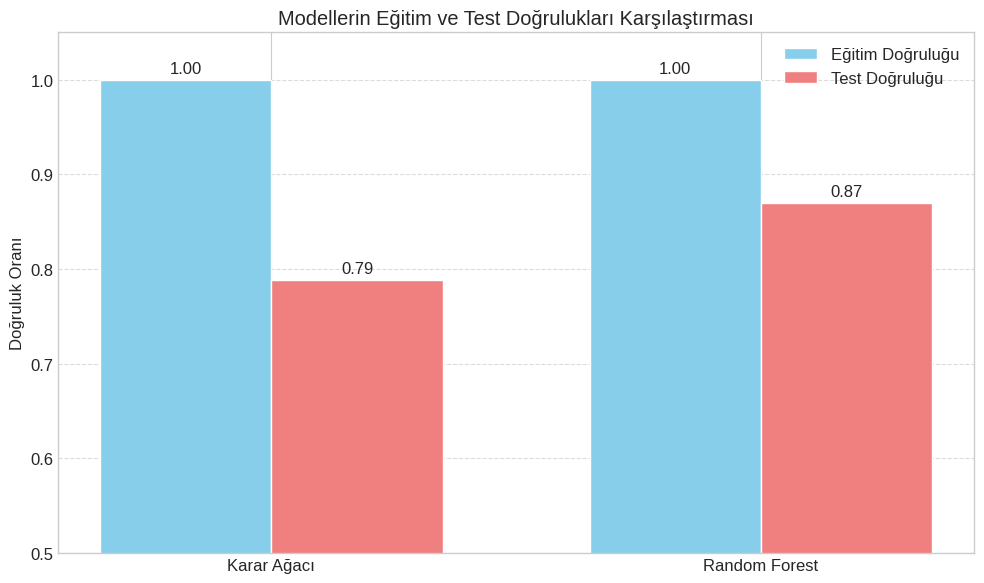

In [21]:
model_names = ['Karar Ağacı', 'Random Forest']
train_accuracies = [dt_train_acc, rf_train_acc]
test_accuracies = [dt_acc, rf_acc]

x = np.arange(len(model_names))  # Model isimleri için etiket konumları
width = 0.35  # Çubukların genişliği

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, train_accuracies, width, label='Eğitim Doğruluğu', color='skyblue')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Doğruluğu', color='lightcoral')

# Eksen ve başlık etiketleri
ax.set_ylabel('Doğruluk Oranı')
ax.set_title('Modellerin Eğitim ve Test Doğrulukları Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0.5, 1.05) # Doğruluk oranları genellikle 0 ile 1 arasındadır, grafiği daha anlamlı hale getirmek için

# Çubukların üzerine değerleri yazma fonksiyonu
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Karmaşıklık Matrisi Görselleştirmeleri

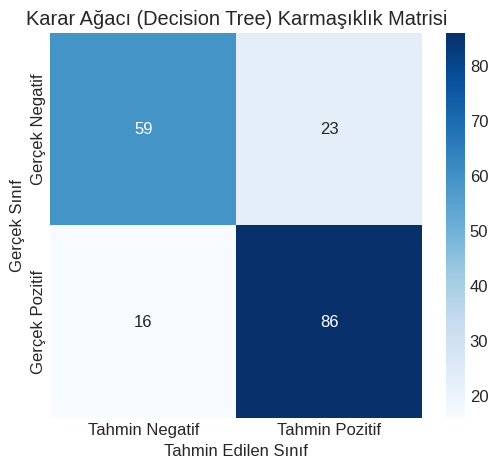

In [19]:
# Karar Ağacı Karmaşıklık Matrisi Heatmap
dt_cm = confusion_matrix(y_test, dt_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin Negatif', 'Tahmin Pozitif'],
            yticklabels=['Gerçek Negatif', 'Gerçek Pozitif'])
plt.title('Karar Ağacı (Decision Tree) Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

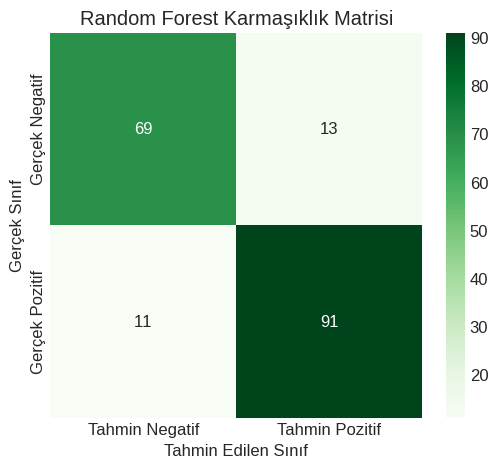

In [20]:
# Random Forest Karmaşıklık Matrisi Heatmap
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tahmin Negatif', 'Tahmin Pozitif'],
            yticklabels=['Gerçek Negatif', 'Gerçek Pozitif'])
plt.title('Random Forest Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

## ROC Eğrisi Çizimi


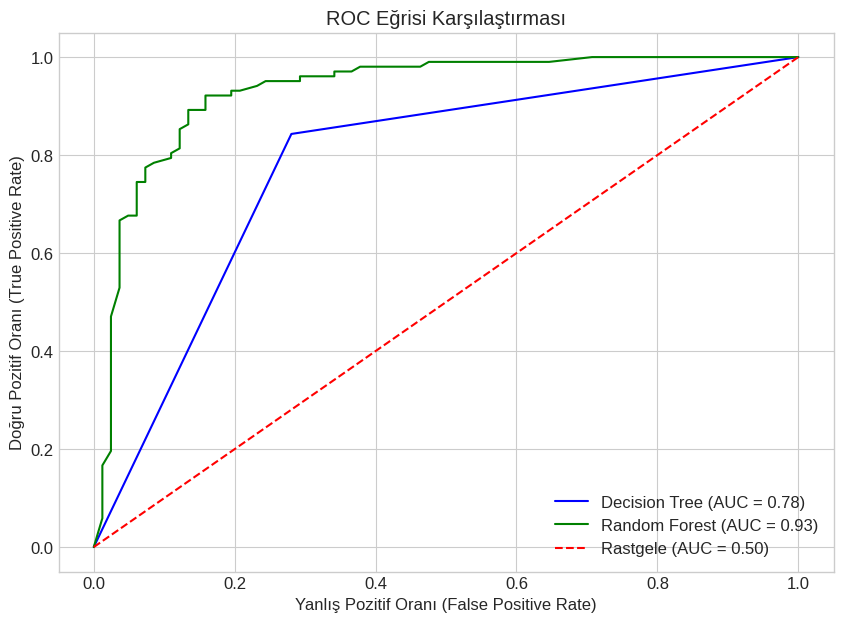

In [17]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(10, 7))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_roc:.2f})', color='blue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele (AUC = 0.50)', color='red')

plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('ROC Eğrisi Karşılaştırması')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()